### 1. Mount Google Drive

First, we need to mount your Google Drive to access its contents. Run the following cell and follow the instructions to authenticate.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 2. Load your data

After mounting, you can navigate to your file. If you have a CSV file, you can load it into a pandas DataFrame. You will need to replace `'/content/drive/MyDrive/path/to/your/data.csv'` with the actual path to your file on Google Drive.

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Replace 'path/to/your/data.csv' with the actual path to your file
file_path = '/content/drive/MyDrive/datasets/concrete_data.csv'
df = pd.read_csv(file_path)

# Display the first 5 rows of the DataFrame
display(df.head())

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [4]:
df.isnull().sum()

,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age,0
Strength,0


## The Concept: Power Transformations

In your previous step, you manually tested Log, Square Root, and Reciprocal transformations. It worked, but it was essentially guesswork to find the best fit.

Power Transformations completely eliminate the guesswork. Instead of you choosing the math, algorithms like Box-Cox and Yeo-Johnson test a massive range of exponents (represented mathematically as $\lambda$) to find the exact perfect mathematical transformation that makes your data as close to a normal bell curve as physically possible.

### Box-Cox
The original powerhouse. It finds the perfect $\lambda$ using this formula:

$$y^{(\lambda)} = \begin{cases} \frac{y^\lambda - 1}{\lambda} & \text{if } \lambda \neq 0 \\ \ln(y) & \text{if } \lambda = 0 \end{cases}$$

**The Catch:** Box-Cox only works on strictly positive numbers ($y > 0$). If your data has a 0 or negative numbers, Box-Cox will instantly crash.

### Yeo-Johnson
The modern upgrade. It adjusts the Box-Cox formula slightly so it can handle zeros and negative numbers perfectly.

Looking at the data, notice how 'Blast Furnace Slag', 'Fly Ash', and 'Superplasticizer' have 0.0 in them? Box-Cox would crash on this dataset unless we artificially add +1 to everything. This is exactly why Yeo-Johnson is the modern default.

## Data Distribution: Before Transformation

Let's visualize the distribution of some key features before applying any transformations to understand their current skewness and characteristics.

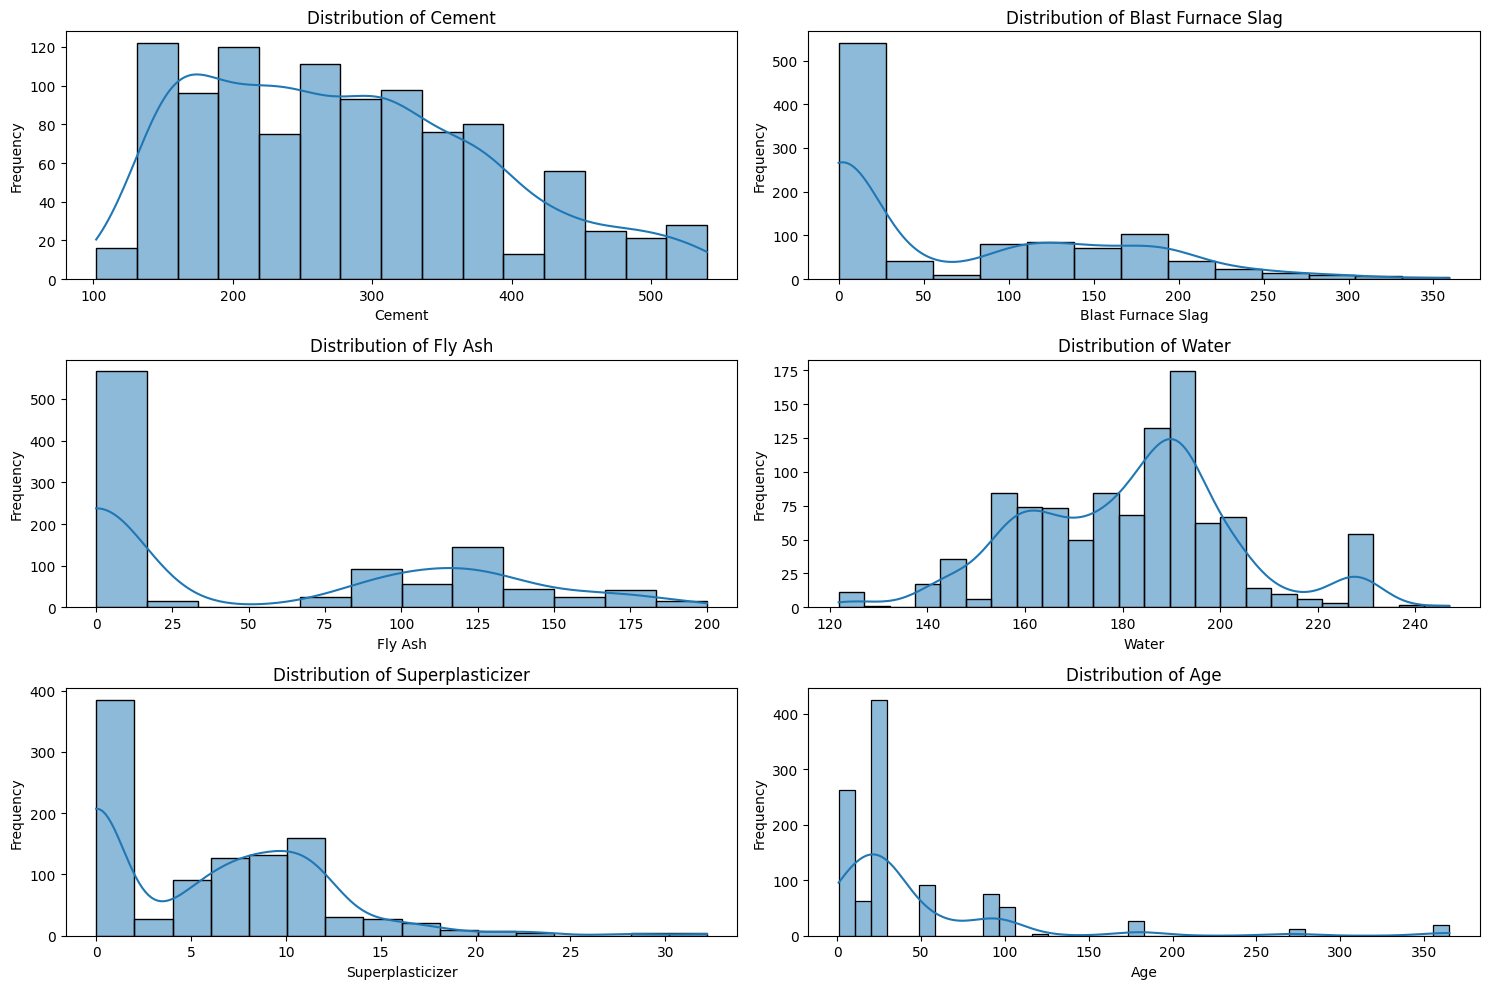

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

features_to_plot = ['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer', 'Age']

plt.figure(figsize=(15, 10))
for i, col in enumerate(features_to_plot):
    plt.subplot(3, 2, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Data Distribution: After Yeo-Johnson Transformation

Now, let's apply the Yeo-Johnson transformation to the training data and visualize the distributions. This should make them more Gaussian (bell-shaped), which is often beneficial for linear models.

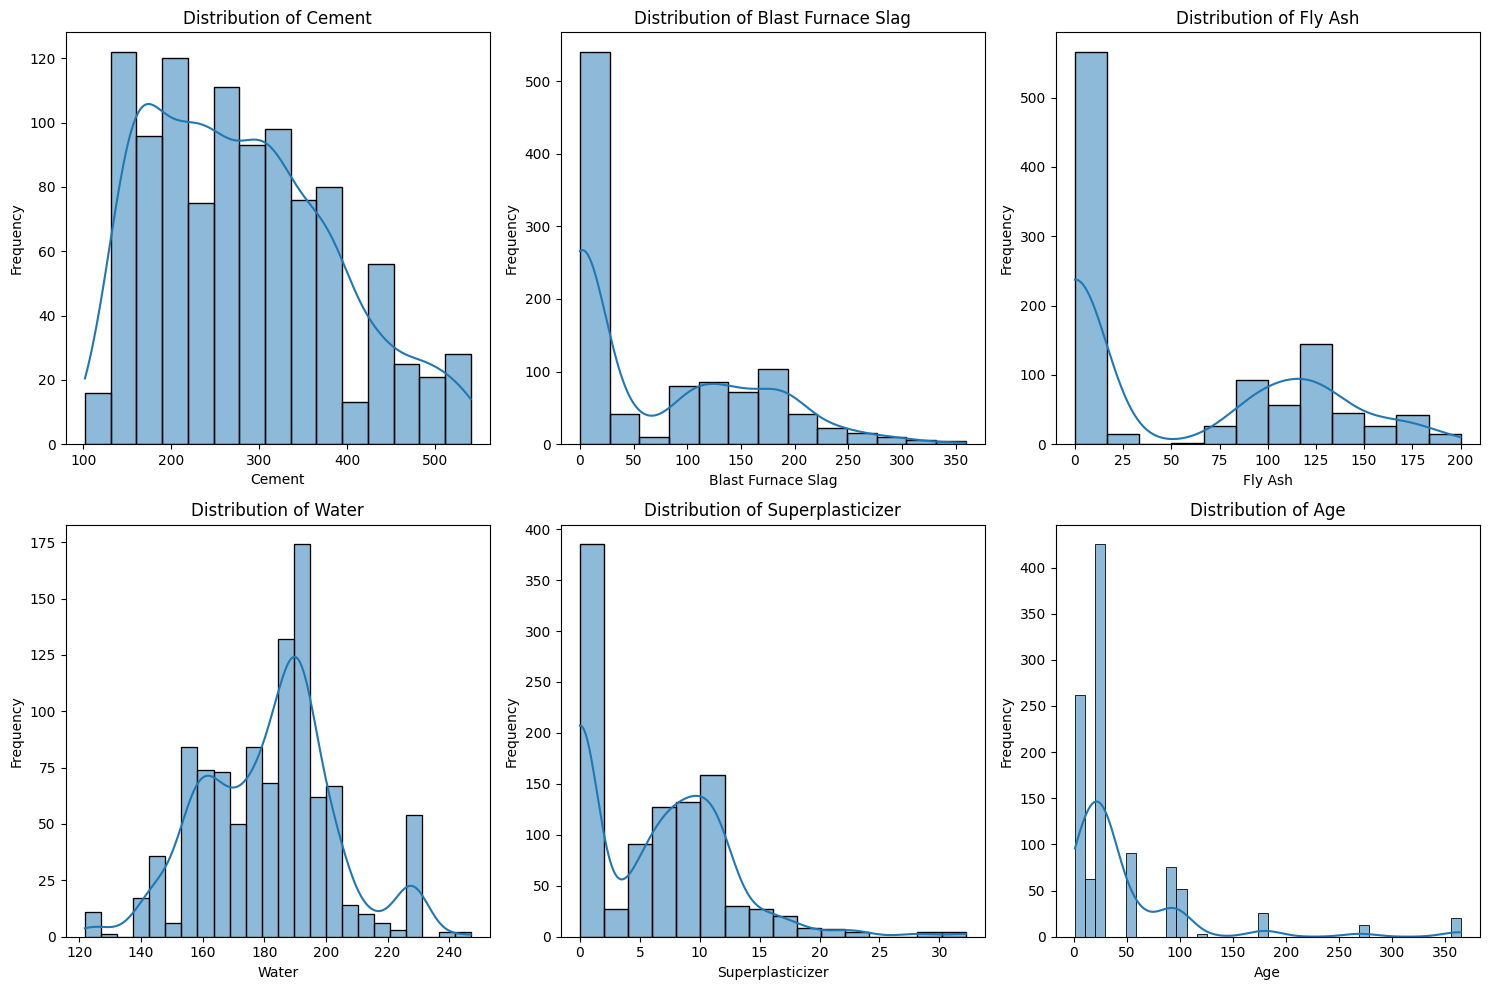

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

features_to_plot = ['Cement', 'Blast Furnace Slag', 'Fly Ash', 'Water', 'Superplasticizer', 'Age']

plt.figure(figsize=(15, 10))
for i, col in enumerate(features_to_plot):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

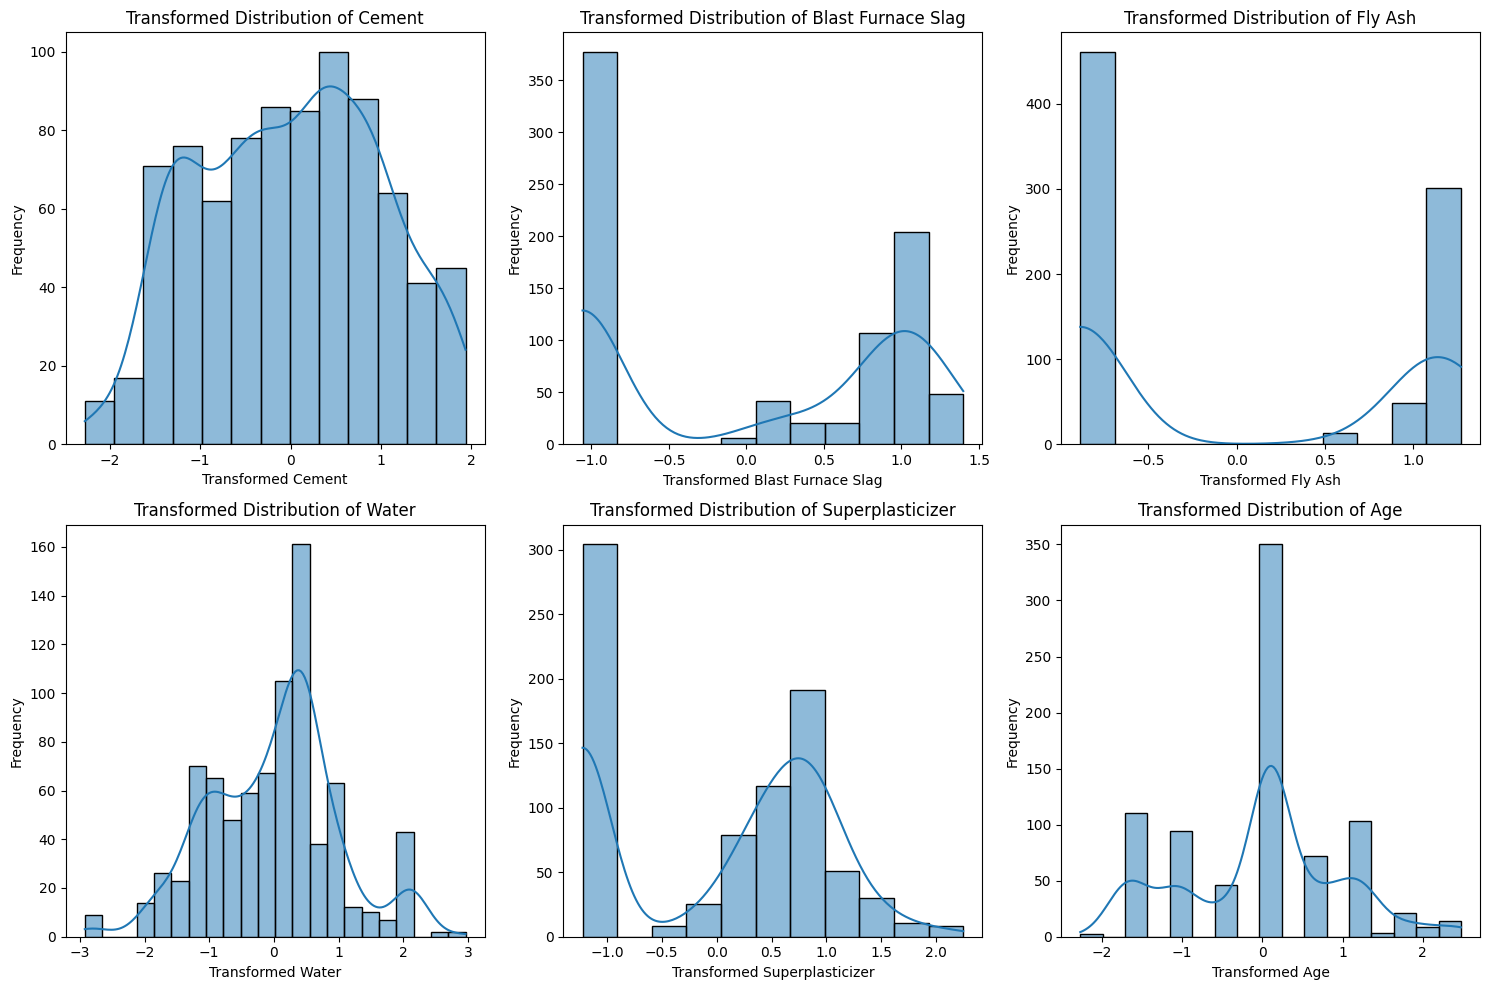

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson', standardize=True)
X_train_transformed = pt.fit_transform(X_train[features_to_plot])
X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=features_to_plot)

plt.figure(figsize=(15, 10))
for i, col in enumerate(features_to_plot):
    plt.subplot(2, 3, i + 1)
    sns.histplot(X_train_transformed_df[col], kde=True)
    plt.title(f'Transformed Distribution of {col}')
    plt.xlabel(f'Transformed {col}')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

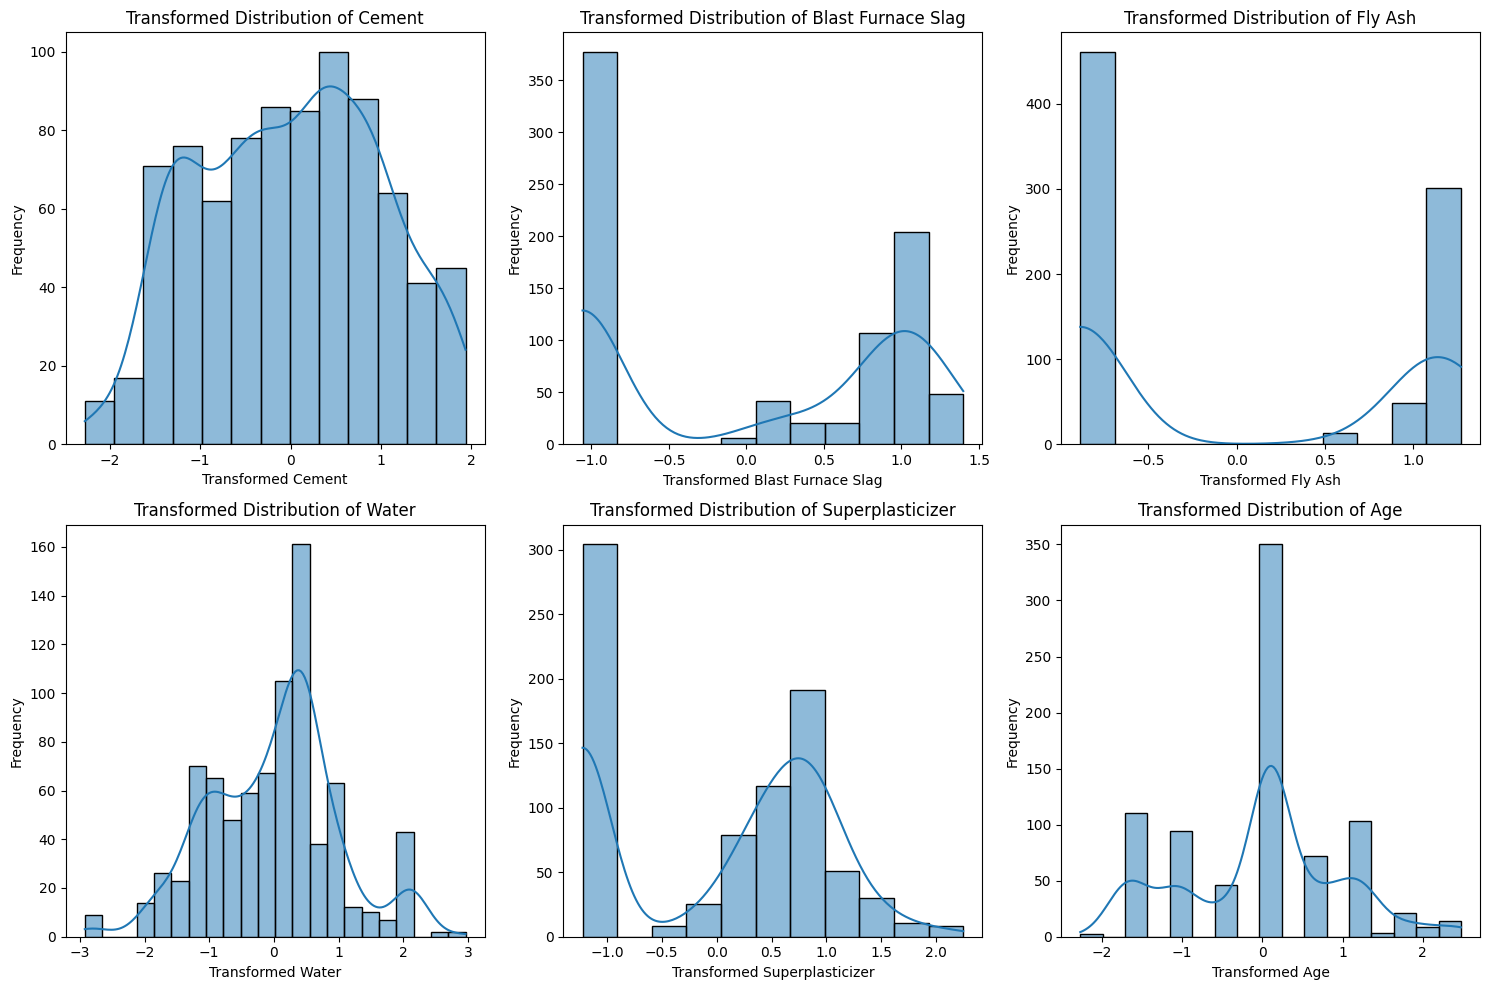

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson', standardize=True)
X_train_transformed = pt.fit_transform(X_train[features_to_plot])
X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=features_to_plot)

plt.figure(figsize=(15, 10))
for i, col in enumerate(features_to_plot):
    plt.subplot(2, 3, i + 1)
    sns.histplot(X_train_transformed_df[col], kde=True)
    plt.title(f'Transformed Distribution of {col}')
    plt.xlabel(f'Transformed {col}')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

In [7]:
# split the data
X = df.drop(columns=['Strength'])
y = df['Strength']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (824, 8)
Testing data shape: (206, 8)


In [9]:
# Test1: the baseline (raw data)
lr_baseline = LinearRegression()
lr_baseline.fit(X_train, y_train)

# predict and evaluate
y_pred_base = lr_baseline.predict(X_test)
r2_base = r2_score(y_test, y_pred_base)
mae_base = mean_absolute_error(y_test, y_pred_base)

print("BASELINE MODEL (Raw Data):")
print(f"R-squared: {r2_base:.4f}")
print(f"MAE:       {mae_base:.2f}")

BASELINE MODEL (Raw Data):
R-squared: 0.6276
MAE:       7.75


In [11]:
# Test2: the professional pipeline (Yeo Johnson)
professional_pipeline = Pipeline(steps=[
    ('power_transform', PowerTransformer(method='yeo-johnson', standardize=True)),
    ('model', LinearRegression())
])

# train the entire pipeline on training data
professional_pipeline.fit(X_train, y_train)

# predict on the unseen testing data
y_pred_transformed = professional_pipeline.predict(X_test)

# Evaluate
r2_transformed = r2_score(y_test, y_pred_transformed)
mae_trans = mean_absolute_error(y_test, y_pred_transformed)

print("PIPELINE MODEL (Yeo-Johnson Transformed):")
print(f"R-squared: {r2_transformed:.4f}")
print(f"MAE:       {mae_trans:.2f}")

PIPELINE MODEL (Yeo-Johnson Transformed):
R-squared: 0.8162
MAE:       5.55


## Visual Comparison: Actual vs. Predicted Values

Let's visualize the performance of both the baseline (raw data) and the pipeline (Yeo-Johnson transformed) models by comparing their predicted values against the actual values from the test set.

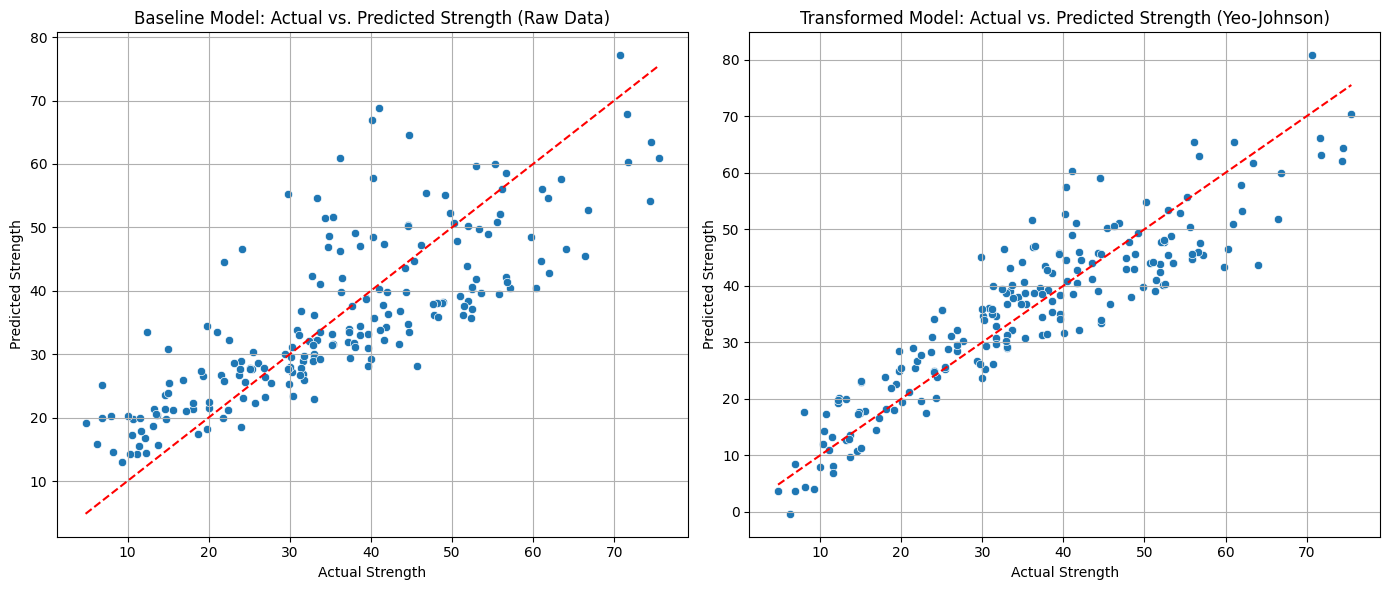

In [19]:
plt.figure(figsize=(14, 6))

# Plot for Baseline Model
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_base)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Baseline Model: Actual vs. Predicted Strength (Raw Data)')
plt.xlabel('Actual Strength')
plt.ylabel('Predicted Strength')
plt.grid(True)

# Plot for Transformed Model
plt.subplot(1, 2, 2)
sns.scatterplot(x=y_test, y=y_pred_transformed)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Transformed Model: Actual vs. Predicted Strength (Yeo-Johnson)')
plt.xlabel('Actual Strength')
plt.ylabel('Predicted Strength')
plt.grid(True)

plt.tight_layout()
plt.show()

From these plots, you can visually observe the impact of the Yeo-Johnson transformation:

*   **Baseline Model (left plot):** The points are more scattered around the red dashed line (representing perfect prediction), indicating a higher degree of error and less accurate predictions.

*   **Transformed Model (right plot):** The points are much tighter and closer to the red dashed line, especially at higher strength values. This demonstrates that the model trained on transformed data provides more accurate and consistent predictions across the range of actual strength values, aligning with the improved R-squared and MAE scores.